# Forberedelsen af data

In [69]:
#Libriaries & Models
import matplotlib
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Layer, LSTM, Dense
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.losses import MeanSquaredError


from IPython.display import clear_output
from skimage.io import imread
from skimage.transform import resize

from scipy.spatial.distance import cdist
from scipy.linalg import pinv
# from sklearn.metrics import mean_squared_error

import os
import pickle

import importlib
import src
importlib.reload(src)

Python random seed set.
NumPy random seed set.


<module 'src' from '/Users/hugojohnson/Desktop/Deep Learning/02456-deep-learning-project/src/__init__.py'>

Access the datasets

In [70]:
dataframes = src.dataset.load_dataframes()
# src.plots.plot_wind(dataframes['wind_speed_15_n']['Mz1'], start=0, end=1000)

Loaded from pickle


Data handling

In [71]:
X_train, X_test, y_train, y_test, scaler_X, scaler_y = src.dataset.load_and_split_data()
# Byg hybrid RBF-LSTM model
num_centers = 10  # Antal centre for RBF-laget

Loaded from pickle
Kombineret datasæts form: (1600005, 21)


# LSTM - RBF Model





In [72]:
# Brugerdefineret RBF-lag i Keras
class RBFLayer(Layer):
    def __init__(self, num_centers, sigma=1.0, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.num_centers = num_centers
        self.sigma = sigma

    def build(self, input_shape):
        # Generér centre tilfældigt ved initialisering
        self.centers = self.add_weight(
            shape=(self.num_centers, input_shape[-1]),
            initializer="random_normal",
            trainable=True,
            name="centers"
        )

    def call(self, inputs):
        # Beregn euklidisk afstand fra input til centre
        inputs_expanded = tf.expand_dims(inputs, 1)  # (batch, 1, features)
        centers_expanded = tf.expand_dims(self.centers, 0)  # (1, num_centers, features)

        # Beregn euklidisk afstand
        distances = tf.reduce_sum(tf.square(inputs_expanded - centers_expanded), axis=-1)
        return tf.exp(-distances / (2 * tf.square(self.sigma)))

model = Sequential([
    RBFLayer(num_centers=num_centers, sigma=1.0, input_shape=(1, X_train.shape[-1])),
    LSTM(50, activation='tanh', return_sequences=False),  # LSTM lag
    Dense(y_train.shape[1])  # Output lag for Mz1, Mz2, Mz3
])

model.compile(optimizer='adam', loss='mse')


/var/folders/_4/qbt6rn_s3_7gh2mhy42959c80000gn/T/ipykernel_34045/1559288091.py:4: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(RBFLayer, self).__init__(**kwargs)


# Training the model

In [73]:
print(history)

In [75]:
retrain_model = False
model_save_path = os.path.join('models', 'peter-lstm-1.h5')

if retrain_model == False and os.path.exists(model_save_path):
    get_custom_objects().update({'RBFLayer': RBFLayer, 'mse': MeanSquaredError})
    model = load_model(model_save_path)
    print("Loaded model from disk")
else:
    history = model.fit(X_train, y_train, epochs=1, batch_size=32, validation_split=0.2, verbose=1)
    model.save(model_save_path)
    print("Generated and saved model to .h5 file")



# Forudsig output for testdata
y_pred = model.predict(X_test)


# Omvend normalisering af y_pred og y_test
y_pred = scaler_y.inverse_transform(y_pred)
y_test = scaler_y.inverse_transform(y_test)

# Beregn MSE
mse = MeanSquaredError(y_test, y_pred)
print("Mean Squared Error på testdata:", mse)

/var/folders/_4/qbt6rn_s3_7gh2mhy42959c80000gn/T/ipykernel_34045/1559288091.py:4: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(RBFLayer, self).__init__(**kwargs)


Loaded model from disk
10001/10001 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

<class 'numpy.ndarray'>


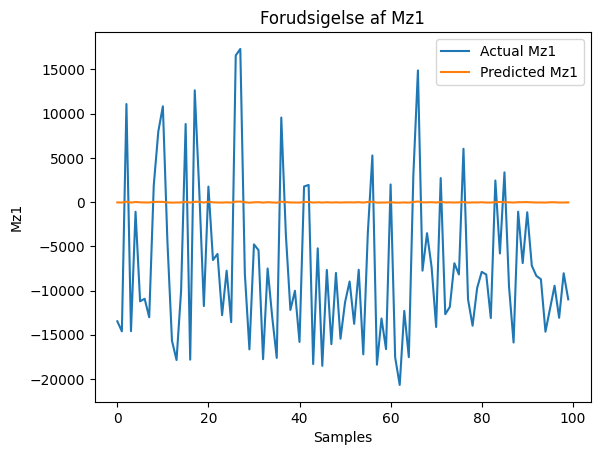

In [59]:
print(type(y_pred[:10]))

# Mz1
# plt.subplot(1, 3, 1)
plt.plot(y_test[:, 1][:100], label='Actual Mz1')
plt.plot(y_pred[:, 1][:100], label='Predicted Mz1')
plt.xlabel('Samples')
plt.ylabel('Mz1')
plt.legend()
plt.title("Forudsigelse af Mz1")

# # Mz2
# plt.subplot(1, 3, 2)
# plt.plot(y_test[:, 1], label='Actual Mz2')
# plt.plot(y_pred[:, 1], label='Predicted Mz2')
# plt.xlabel('Samples')
# plt.ylabel('Mz2')
# plt.legend()
# plt.title("Forudsigelse af Mz2")

# # Mz3
# plt.subplot(1, 3, 3)
# plt.plot(y_test[:, 2], label='Actual Mz3')
# plt.plot(y_pred[:, 2], label='Predicted Mz3')
# plt.xlabel('Samples')
# plt.ylabel('Mz3')
# plt.legend()
# plt.title("Forudsigelse af Mz3")

# plt.tight_layout()
plt.show()